# London Bicycles: Exploratory Data Analysis & Strategic Business Findings
This notebook connects to the `london_bikes` Star Schema (Fact and Dimension tables) inside Google BigQuery. We leverage `pandas` and `sqlalchemy-bigquery` to execute analytical workloads addressing four critical business insights identified by the engineering team.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')

# Set visual style for executive-level charts
plt.style.use('ggplot')
sns.set_palette("coolwarm")

# Connect to BigQuery using SQLAlchemy
PROJECT_ID = 'bigdatads2f'
DATASET_ID = 'london_bikes'
engine = create_engine(f'bigquery://{PROJECT_ID}/{DATASET_ID}')
print("Securely connected to Google BigQuery Data Warehouse.")

Securely connected to Google BigQuery Data Warehouse.


--- 
## Finding 1: Revenue Is Dangerously Seasonal
We extract total trips aggregated by month to identify systemic fluctuations heavily impacting top-line revenues during off-seasons.

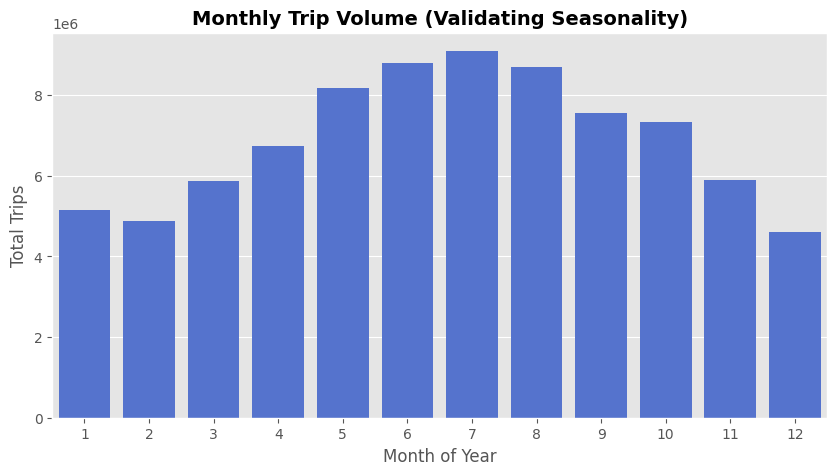

In [2]:
query_seasonality = """
SELECT 
  EXTRACT(MONTH FROM start_date) as month,
  COUNT(trip_id) as total_trips
FROM `bigdatads2f.london_bikes.fact_trips`
GROUP BY month
ORDER BY month
"""
df_seasonality = pd.read_sql(query_seasonality, engine)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_seasonality, x='month', y='total_trips', color='royalblue')
plt.title('Monthly Trip Volume (Validating Seasonality)', fontsize=14, fontweight='bold')
plt.xlabel('Month of Year', fontsize=12)
plt.ylabel('Total Trips', fontsize=12)
plt.show()

--- 
## Finding 2: Revenue Opportunity Is Concentrated in Certain Hours of a Day
Evaluating trip frequency by hour reveals immense pressure on the logistics network natively tied to commuter schedules.

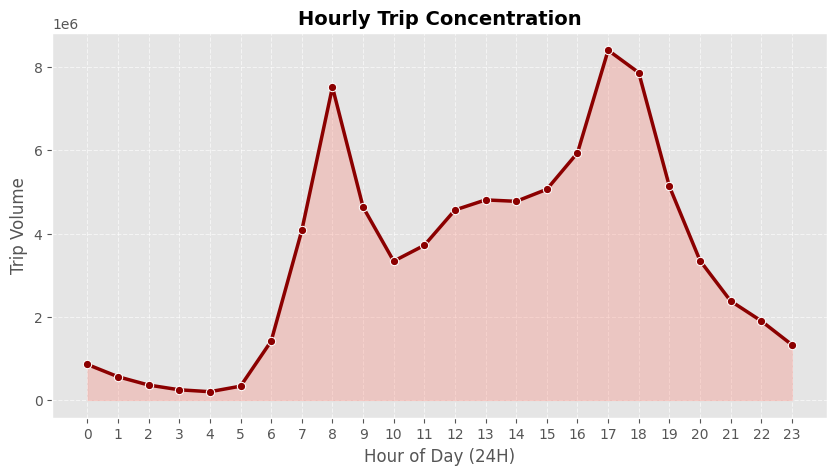

In [3]:
query_hourly = """
SELECT 
  EXTRACT(HOUR FROM start_date) as hour,
  COUNT(trip_id) as total_trips
FROM `bigdatads2f.london_bikes.fact_trips`
GROUP BY hour
ORDER BY hour
"""
df_hourly = pd.read_sql(query_hourly, engine)

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_hourly, x='hour', y='total_trips', marker='o', linewidth=2.5, color='darkred')
plt.title('Hourly Trip Concentration', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (24H)', fontsize=12)
plt.ylabel('Trip Volume', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(0, 24))
plt.fill_between(df_hourly['hour'], df_hourly['total_trips'], color='salmon', alpha=0.3)
plt.show()

--- 
## Finding 3: Demand Spikes Are Invisible Until It Is Too Late
We calculate the rolling volatility specifically looking for huge daily deviation spikes in trip volume, proving that day-over-day changes are highly unpredictable, causing operational backlog.

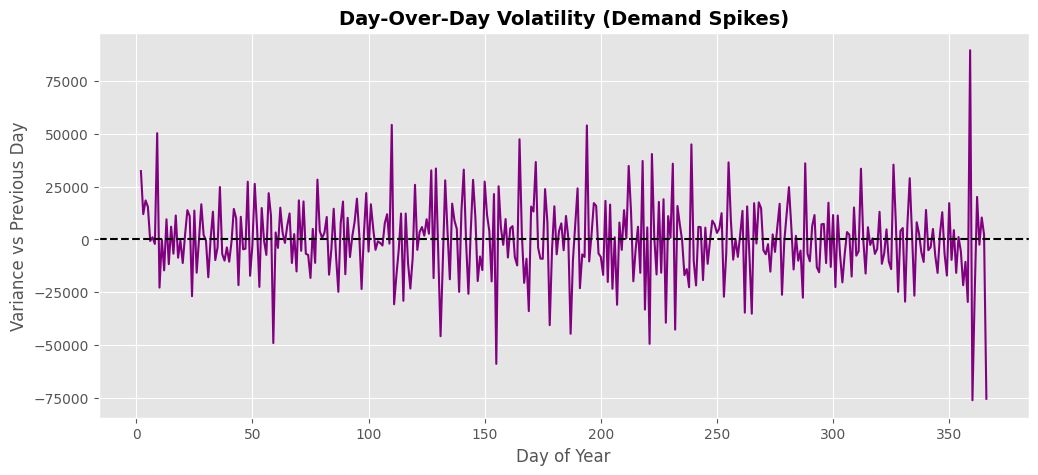

In [4]:
query_spikes = """
WITH daily_trips AS (
  SELECT 
    EXTRACT(DAYOFYEAR FROM start_date) as day_of_year,
    COUNT(trip_id) as daily_volume
  FROM `bigdatads2f.london_bikes.fact_trips`
  GROUP BY day_of_year
)
SELECT *, 
  daily_volume - LAG(daily_volume) OVER(ORDER BY day_of_year) as daily_variance
FROM daily_trips
ORDER BY day_of_year
"""
df_spikes = pd.read_sql(query_spikes, engine)

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_spikes, x='day_of_year', y='daily_variance', color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.title('Day-Over-Day Volatility (Demand Spikes)', fontsize=14, fontweight='bold')
plt.xlabel('Day of Year', fontsize=12)
plt.ylabel('Variance vs Previous Day', fontsize=12)
plt.show()

--- 
## Finding 4: Key Volume Is Concentrated in Just a Few Stations
A Pareto analysis of the stations reveals that a tiny percent of outposts handle massive percentages of our overall business throughput.

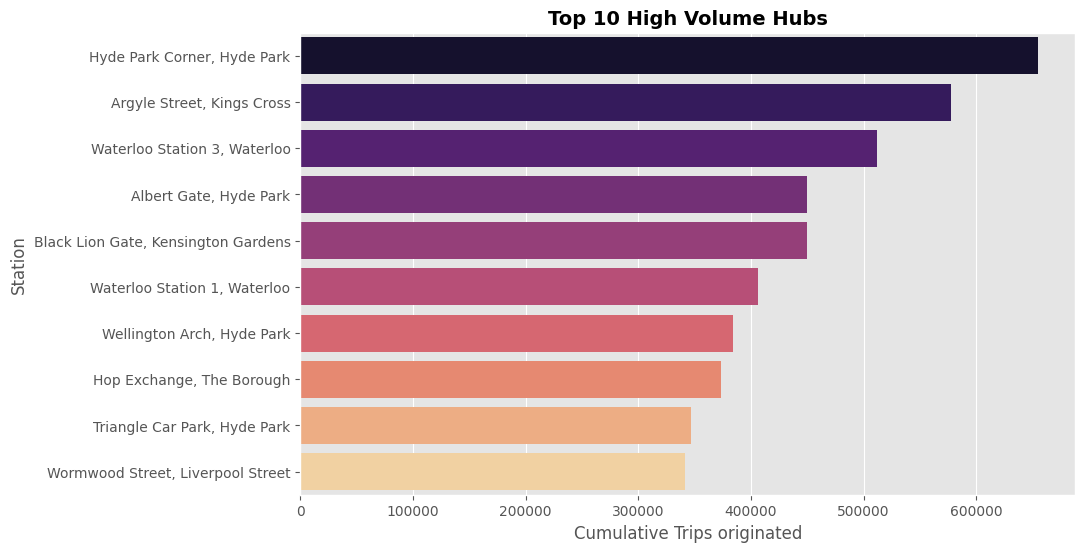

In [5]:
query_stations = """
SELECT 
  s.station_name,
  COUNT(f.trip_id) as total_trips
FROM `bigdatads2f.london_bikes.fact_trips` f
JOIN `bigdatads2f.london_bikes.dim_stations` s ON f.start_station_id = s.station_id
GROUP BY s.station_name
ORDER BY total_trips DESC
LIMIT 10
"""
df_stations = pd.read_sql(query_stations, engine)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_stations, x='total_trips', y='station_name', palette='magma')
plt.title('Top 10 High Volume Hubs', fontsize=14, fontweight='bold')
plt.xlabel('Cumulative Trips originated', fontsize=12)
plt.ylabel('Station', fontsize=12)
plt.show()